<a href="https://colab.research.google.com/github/NamNam9252/Computer_vision/blob/main/cv_assignment_3(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

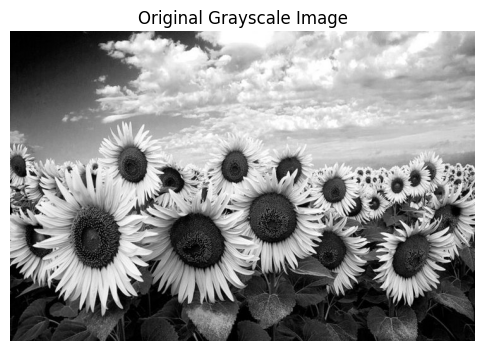

In [47]:
# Load image in grayscale
img = cv2.imread("img2.png", cv2.IMREAD_GRAYSCALE)

# Display original image
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [48]:
def gaussian_kernel(sigma):
    """
    Create a 2D Gaussian kernel manually.
    """

    kernel_size = int(6 * sigma + 1)

    if kernel_size % 2 == 0:
        kernel_size += 1

    radius = kernel_size // 2

    x = np.arange(-radius, radius + 1)
    y = np.arange(-radius, radius + 1)

    X, Y = np.meshgrid(x, y)

    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

    # Normalize so that kernel sum = 1
    kernel = kernel / np.sum(kernel)

    return kernel

In [49]:
def gaussian_scale_space(image, sigma):
    """
    Generate one Gaussian-smoothed image for a given sigma.
    """

    kernel = gaussian_kernel(sigma)

    smoothed = convolve2d(
        image,
        kernel,
        mode="same",
        boundary="symm"
    )

    return smoothed

In [50]:
# Required sigma values
sigmas = [1, 2, 4, 8, 16]

# Dictionary to store filtered images
scale_space = {}

for sigma in sigmas:
    scale_space[sigma] = gaussian_scale_space(img, sigma)

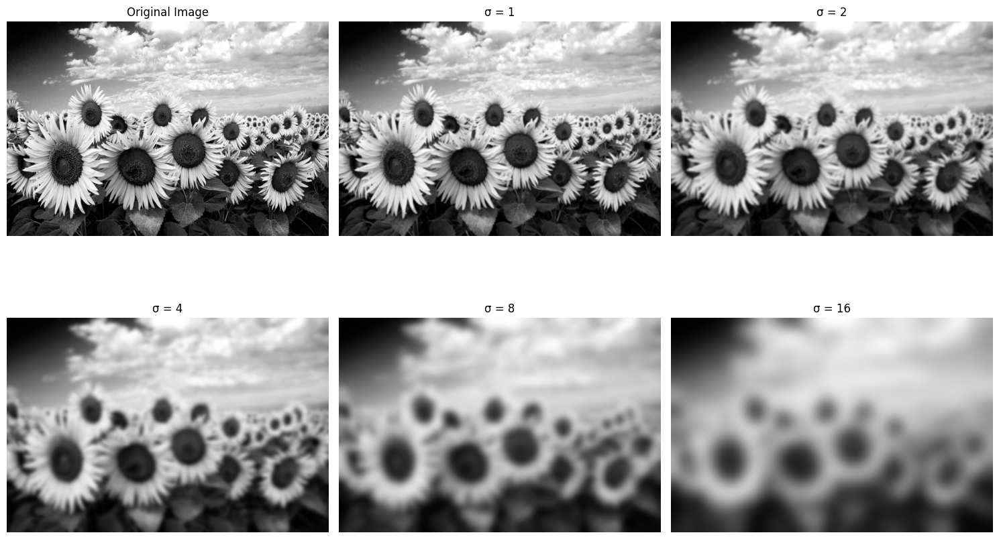

In [51]:
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Gaussian scale-space images
for i, sigma in enumerate(sigmas):

    plt.subplot(2, 3, i + 2)

    plt.imshow(scale_space[sigma], cmap="gray")

    plt.title(f"σ = {sigma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visual Impact of Increasing σ

| Aspect                   | Small σ (1–2)    | Medium σ (4–8)                  | Large σ (16)                 |
| ------------------------ | ---------------- | ------------------------------- | ---------------------------- |
| **Fine details**         | Mostly preserved | Fine details start disappearing | Fine details largely removed |
| **High-frequency noise** | Slightly reduced | Significantly reduced           | Strongly reduced             |
| **Edge boundaries**      | Sharp and clear  | Smoother and less sharp         | Very blurred                 |
| **Small structures**     | Clearly visible  | Some begin to disappear         | Mostly disappear             |
| **Large structures**     | Visible          | More prominent                  | Mainly remain visible        |
| **Overall image**        | Less blurred     | Moderately blurred              | Heavily blurred              |

**Overall:** As **σ increases, smoothing increases**. Fine details, noise, and small structures are progressively removed, while larger structures remain visible.


# Question 2

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

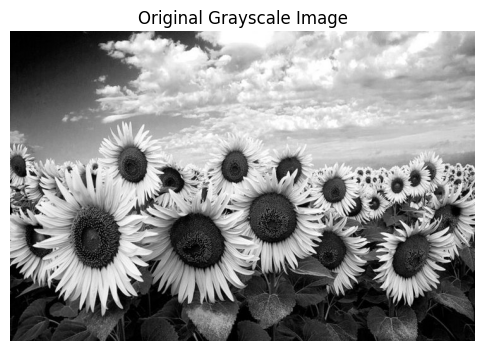

Original image dimensions: 736 × 490


In [53]:
# Load the image as a grayscale image
img = cv2.imread("img2.png", cv2.IMREAD_GRAYSCALE)

# Get image dimensions
height, width = img.shape[:2]

# Display original image
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Original image dimensions:", width, "×", height)

In [54]:
def gaussian_kernel(sigma):
    """
    Create a 2D Gaussian kernel manually.
    """

    kernel_size = int(6 * sigma + 1)

    if kernel_size % 2 == 0:
        kernel_size += 1

    radius = kernel_size // 2

    x = np.arange(-radius, radius + 1)
    y = np.arange(-radius, radius + 1)

    X, Y = np.meshgrid(x, y)

    kernel = np.exp(
        -(X**2 + Y**2) / (2 * sigma**2)
    )

    # Normalize kernel
    kernel = kernel / np.sum(kernel)

    return kernel

In [55]:
def gaussian_smooth(image, sigma):
    """
    Apply Gaussian smoothing using the manually
    generated Gaussian kernel.
    """

    kernel = gaussian_kernel(sigma)

    smoothed = convolve2d(
        image,
        kernel,
        mode="same",
        boundary="symm"
    )

    return smoothed

In [56]:
num_levels = 5

pyramid = [img]

for i in range(1, num_levels):

    # Step 1: Gaussian smoothing
    blurred = gaussian_smooth(
        pyramid[i - 1],
        sigma=1
    )

    # Step 2: Downsample by factor of 2
    downsampled = blurred[::2, ::2]

    pyramid.append(downsampled)

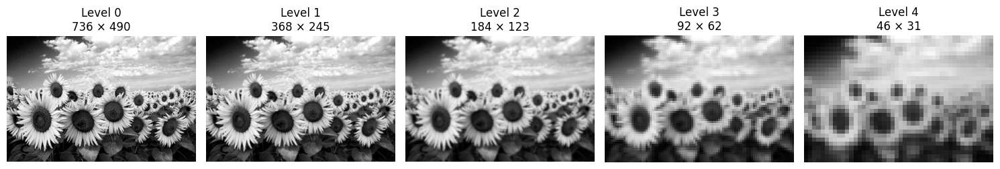

In [57]:
plt.figure(figsize=(15, 5))

for i, image in enumerate(pyramid):

    plt.subplot(1, num_levels, i + 1)

    plt.imshow(image, cmap="gray")

    # Get dimensions
    height, width = image.shape

    plt.title(f"Level {i}\n{width} × {height}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
print("Gaussian Pyramid Dimensions")
print("----------------------------")

for i, image in enumerate(pyramid):

    height, width = image.shape

    print(f"Level {i}: {width} × {height}")

Gaussian Pyramid Dimensions
----------------------------
Level 0: 736 × 490
Level 1: 368 × 245
Level 2: 184 × 123
Level 3: 92 × 62
Level 4: 46 × 31


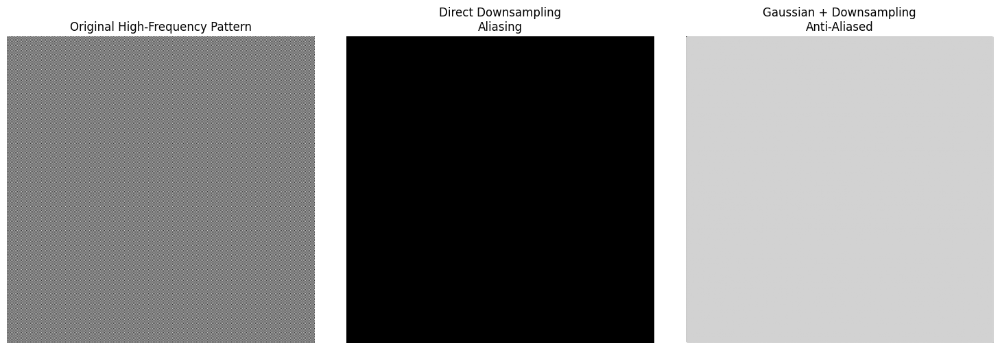

In [59]:
# Create a high-frequency checkerboard pattern

size = 512

checkerboard = np.indices(
    (size, size)
).sum(axis=0) % 2

checkerboard = checkerboard.astype(np.float32)


# Direct downsampling
checker_direct = checkerboard[::2, ::2]


# Gaussian smoothing BEFORE downsampling
checker_smooth = gaussian_smooth(
    checkerboard,
    sigma=1
)

checker_anti_aliased = checker_smooth[::2, ::2]


# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(
    checkerboard,
    cmap="gray"
)
plt.title("Original High-Frequency Pattern")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(
    checker_direct,
    cmap="gray"
)
plt.title("Direct Downsampling\nAliasing")
plt.axis("off")


plt.subplot(1, 3, 3)
plt.imshow(
    checker_anti_aliased,
    cmap="gray"
)
plt.title("Gaussian + Downsampling\nAnti-Aliased")
plt.axis("off")


plt.tight_layout()
plt.show()

### Why Gaussian Filtering is Needed Before Downsampling

When an image is downsampled by a factor of 2, we keep only every second pixel in both the horizontal and vertical directions. This reduces the spatial resolution of the image.

The original image may contain high-frequency details such as fine textures, thin lines, sharp edges, and noise. After downsampling, these details may be too fine to represent correctly. This can create false patterns and distortions called **aliasing**.

To reduce aliasing, we first apply Gaussian smoothing:

$$
I_{\text{smooth}}(x,y)
=
G(x,y,\sigma) * I(x,y)
$$

The Gaussian filter acts as a **low-pass filter**. It reduces high-frequency components while preserving the important larger-scale structures of the image.

After smoothing, the image is downsampled:

$$
I_{\text{new}}
=
I_{\text{smooth}} \downarrow 2
$$

where $\downarrow 2$ represents downsampling by a factor of 2.

Therefore, the correct order is:

$$
\boxed{
\text{Gaussian Smoothing}
\rightarrow
\text{Downsampling}
}
$$

This order is important because if we downsample first, high-frequency information can cause aliasing and may already be lost. Applying Gaussian smoothing afterward cannot recover this lost information.

According to the sampling principle, downsampling reduces the sampling rate and therefore reduces the range of frequencies that can be represented correctly. Gaussian filtering suppresses frequencies that are too high before sampling, thereby reducing aliasing.

Thus, Gaussian anti-aliasing filtering produces a more stable and accurate lower-resolution image while preserving the important spatial structures.

# Question 3

In [60]:
from scipy.signal import convolve2d

def laplacian(image):
    """
    Compute the Laplacian using a 3x3 Laplacian kernel.
    """

    laplacian_kernel = np.array([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ], dtype=np.float64)

    return convolve2d(
        image,
        laplacian_kernel,
        mode="same",
        boundary="symm"
    )

In [61]:
def compute_log_response(scale_space, sigma):
    """
    Compute scale-normalized Laplacian-of-Gaussian response.
    """

    image = scale_space[sigma]

    lap = laplacian(image)

    response = (sigma ** 2) * np.abs(lap)

    return response

In [62]:
log_responses = {}

for sigma in sigmas:
    log_responses[sigma] = compute_log_response(scale_space, sigma)

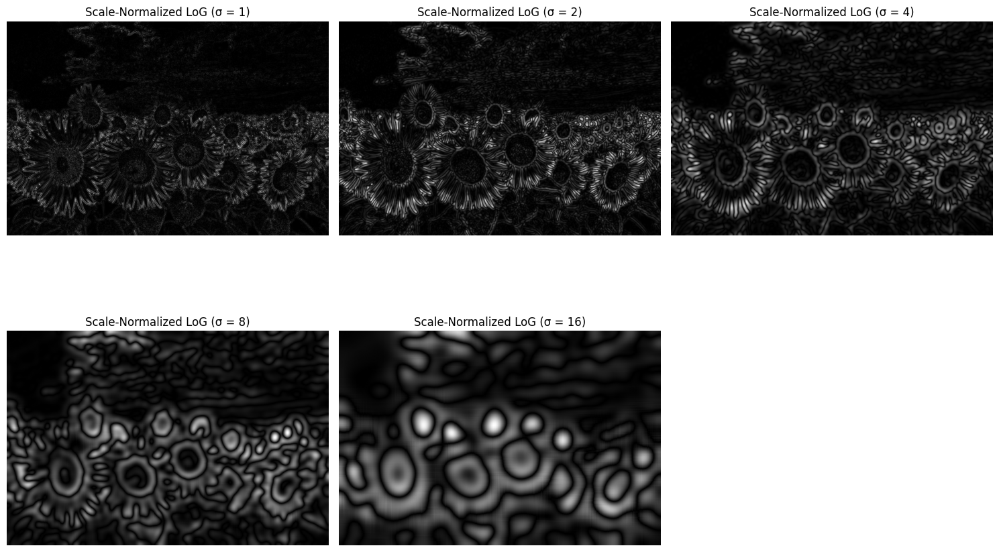

In [63]:
plt.figure(figsize=(15, 10))

for i, sigma in enumerate(sigmas):
    plt.subplot(2, 3, i + 1)

    plt.imshow(log_responses[sigma], cmap="gray")
    plt.title(f"Scale-Normalized LoG (σ = {sigma})")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Scale Normalization and Scale Invariance

The Laplacian measures how rapidly the image intensity changes around a pixel. When we change the Gaussian scale \(\sigma\), the amount of smoothing also changes.

For a larger \(\sigma\):

$$
\text{More smoothing}
\rightarrow
\text{weaker fine details}
\rightarrow
\text{different Laplacian response}
$$

Therefore, the raw Laplacian responses at different scales cannot be directly compared.

To make the responses comparable, we multiply the Laplacian by \(\sigma^2\):

$$
\boxed{
R(x,y,\sigma)
=
\sigma^2
\left|
\nabla^2L(x,y,\sigma)
\right|
}
$$

Here, \(\sigma^2\) is called the **scale-normalization factor**.

It compensates for the change in the magnitude of the second-order derivative as the scale changes. This allows us to compare the response of the **same image structure at different scales**.

For example:

$$
\text{Small structure}
\rightarrow
\text{detected at small }\sigma
$$

$$
\text{Large structure}
\rightarrow
\text{detected at large }\sigma
$$

Because the responses are normalized, the detector can identify a structure according to its appropriate scale rather than depending only on its absolute size in the image.

Therefore:

$$
\boxed{
\sigma^2
\rightarrow
\text{normalizes the Laplacian}
\rightarrow
\text{responses become comparable across scales}
\rightarrow
\text{scale-invariant detection}
}
$$

**Note:** Scale normalization does not mean that the numerical response will be exactly identical at every scale. It provides the normalization needed to make responses meaningfully comparable across scales.


# Question 4


In [64]:
log_responses

{1: array([[0.        , 0.        , 0.        , ..., 2.17718995, 1.1277201 ,
         0.2993287 ],
        [0.        , 0.        , 0.        , ..., 0.02757209, 0.90042217,
         1.66603382],
        [0.        , 0.        , 0.        , ..., 0.09417097, 0.54648763,
         0.93874598],
        ...,
        [1.44609984, 2.56002148, 6.18166303, ..., 2.16395422, 0.69090703,
         3.31879831],
        [1.89406975, 4.36142097, 4.28824958, ..., 1.18148378, 2.16090281,
         0.29789776],
        [1.8441744 , 5.24360708, 3.12710769, ..., 0.52936804, 1.72539897,
         1.31980038]]),
 2: array([[0.        , 0.        , 0.        , ..., 3.32546618, 1.73344164,
         0.68032237],
        [0.        , 0.        , 0.        , ..., 2.58405196, 1.33111386,
         0.48270119],
        [0.        , 0.        , 0.        , ..., 1.85071614, 1.1313777 ,
         0.61055   ],
        ...,
        [9.41796788, 8.84545482, 6.2167044 , ..., 0.70796416, 0.08535932,
         0.83010869],
      

In [65]:
# Create 3D scale-space volume
scale_space_volume = np.stack(
    [log_responses[sigma] for sigma in sigmas],
    axis=2
)

print("Scale-space volume shape:", scale_space_volume.shape)

Scale-space volume shape: (490, 736, 5)


In [66]:
def find_scale_space_extrema(volume, threshold):
    """
    Detect local maxima and minima in a 3D scale-space volume.

    Each candidate is compared with its 26-neighborhood:
    8 neighbors at the same scale,
    9 neighbors at the scale above,
    9 neighbors at the scale below.
    """

    extrema = []

    height, width, num_scales = volume.shape

    # Ignore image boundaries and first/last scale
    for s in range(1, num_scales - 1):

        for x in range(1, height - 1):

            for y in range(1, width - 1):

                value = volume[x, y, s]

                # Extract 3 × 3 × 3 neighborhood
                neighborhood = volume[
                    x-1:x+2,
                    y-1:y+2,
                    s-1:s+2
                ]

                # Convert neighborhood to 1D
                neighbors = neighborhood.flatten()

                # Remove the center pixel
                neighbors = np.delete(neighbors, 13)

                # Check for strong local maximum
                if value > threshold and value > neighbors.max():

                    extrema.append(
                        (x, y, s, value, "maximum")
                    )

                # Check for strong local minimum
                elif value < -threshold and value < neighbors.min():

                    extrema.append(
                        (x, y, s, value, "minimum")
                    )

    return extrema

In [67]:
threshold = 20

extrema = find_scale_space_extrema(
    scale_space_volume,
    threshold
)

print("Number of detected extrema:", len(extrema))

Number of detected extrema: 1852


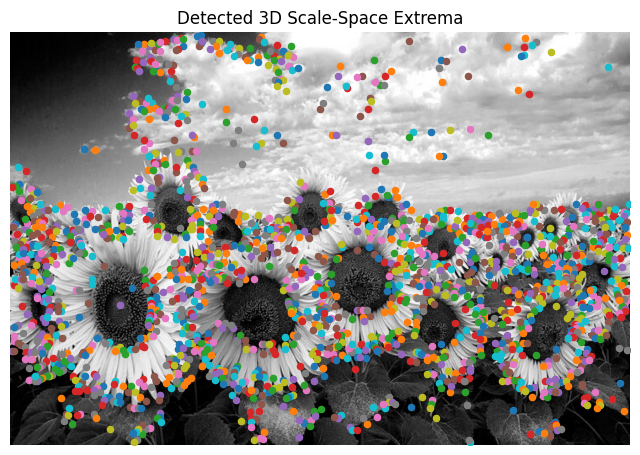

In [68]:
plt.figure(figsize=(8, 8))

plt.imshow(img, cmap="gray")

for x, y, s, value, kind in extrema:
    plt.scatter(y, x, s=20)

plt.title("Detected 3D Scale-Space Extrema")
plt.axis("off")
plt.show()

# Question 5

In [69]:
blob_features = []

for x, y, scale_index, value, kind in extrema:

    sigma = sigmas[scale_index]

    # Estimate blob radius
    radius = np.sqrt(2) * sigma

    blob_features.append(
        (x, y, sigma, radius, value, kind)
    )

print("Number of detected blobs:", len(blob_features))

Number of detected blobs: 1852


In [70]:
for feature in blob_features:
    x, y, sigma, radius, value, kind = feature

    print(
        f"Center = ({x}, {y}), "
        f"σ = {sigma}, "
        f"Radius = {radius:.2f}, "
        f"Type = {kind}"
    )

Center = (3, 226), σ = 2, Radius = 2.83, Type = maximum
Center = (5, 298), σ = 2, Radius = 2.83, Type = maximum
Center = (6, 195), σ = 2, Radius = 2.83, Type = maximum
Center = (6, 203), σ = 2, Radius = 2.83, Type = maximum
Center = (8, 194), σ = 2, Radius = 2.83, Type = maximum
Center = (8, 295), σ = 2, Radius = 2.83, Type = maximum
Center = (9, 198), σ = 2, Radius = 2.83, Type = maximum
Center = (10, 241), σ = 2, Radius = 2.83, Type = maximum
Center = (10, 248), σ = 2, Radius = 2.83, Type = maximum
Center = (11, 301), σ = 2, Radius = 2.83, Type = maximum
Center = (12, 226), σ = 2, Radius = 2.83, Type = maximum
Center = (13, 159), σ = 2, Radius = 2.83, Type = maximum
Center = (14, 175), σ = 2, Radius = 2.83, Type = maximum
Center = (15, 317), σ = 2, Radius = 2.83, Type = maximum
Center = (16, 166), σ = 2, Radius = 2.83, Type = maximum
Center = (16, 224), σ = 2, Radius = 2.83, Type = maximum
Center = (16, 261), σ = 2, Radius = 2.83, Type = maximum
Center = (17, 151), σ = 2, Radius = 2.

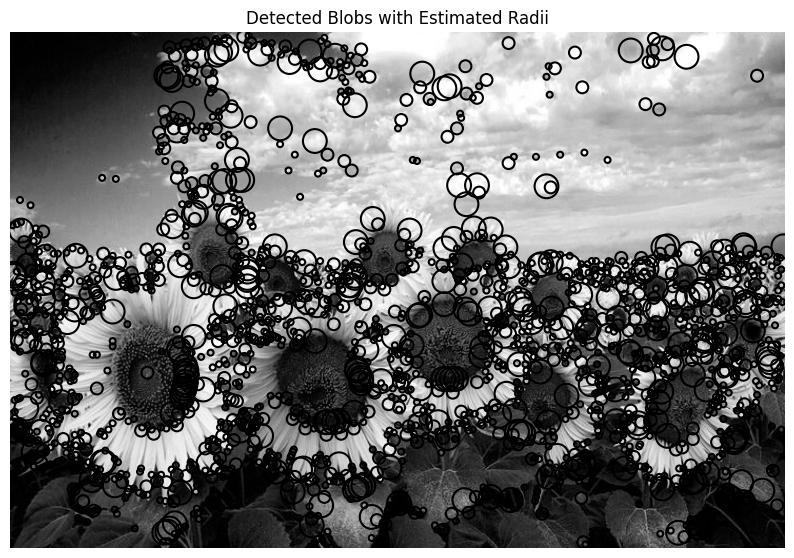

In [71]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(img, cmap="gray")

for x, y, sigma, radius, value, kind in blob_features:

    circle = Circle(
        (y, x),
        radius,
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(circle)

ax.set_title("Detected Blobs with Estimated Radii")
ax.axis("off")

plt.show()

# Question 6

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from matplotlib.patches import Circle

In [73]:
def gaussian_kernel(sigma):
    kernel_size = int(6 * sigma + 1)

    if kernel_size % 2 == 0:
        kernel_size += 1

    radius = kernel_size // 2

    x = np.arange(-radius, radius + 1)
    X, Y = np.meshgrid(x, x)

    kernel = np.exp(
        -(X**2 + Y**2) / (2 * sigma**2)
    )

    kernel = kernel / np.sum(kernel)

    return kernel


def gaussian_scale_space(image, sigma):
    kernel = gaussian_kernel(sigma)

    return convolve2d(
        image,
        kernel,
        mode="same",
        boundary="symm"
    )


def laplacian(image):

    laplacian_kernel = np.array([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ], dtype=np.float64)

    return convolve2d(
        image,
        laplacian_kernel,
        mode="same",
        boundary="symm"
    )


def compute_log_response(image, sigma):

    smoothed = gaussian_scale_space(image, sigma)

    lap = laplacian(smoothed)

    response = (sigma ** 2) * np.abs(lap)

    return response

In [74]:
sigmas = [1, 2, 4, 8, 16]


def detect_blobs(image, threshold=20):

    # --------------------------------
    # 1. Generate LoG responses
    # --------------------------------
    log_responses = []

    for sigma in sigmas:

        response = compute_log_response(
            image,
            sigma
        )

        log_responses.append(response)

    # --------------------------------
    # 2. Create 3D scale-space volume
    # --------------------------------
    volume = np.stack(
        log_responses,
        axis=2
    )

    # --------------------------------
    # 3. 3D non-maximum suppression
    # --------------------------------
    extrema = []

    height, width, num_scales = volume.shape

    for s in range(1, num_scales - 1):

        for x in range(1, height - 1):

            for y in range(1, width - 1):

                value = volume[x, y, s]

                neighborhood = volume[
                    x-1:x+2,
                    y-1:y+2,
                    s-1:s+2
                ]

                neighbors = neighborhood.flatten()

                # Remove center pixel
                neighbors = np.delete(
                    neighbors,
                    13
                )

                # Since |LoG| is used, responses are positive
                if (
                    value > threshold
                    and value > neighbors.max()
                ):

                    extrema.append(
                        (x, y, s, value)
                    )

    # --------------------------------
    # 4. Estimate blob radius
    # --------------------------------
    blobs = []

    for x, y, scale_index, value in extrema:

        sigma = sigmas[scale_index]

        radius = np.sqrt(2) * sigma

        blobs.append(
            (x, y, sigma, radius, value)
        )

    return blobs

In [75]:
scale_factors = [1.0, 0.75, 0.50, 0.25]

resized_images = {}

for scale in scale_factors:

    height, width = img.shape

    new_width = int(width * scale)
    new_height = int(height * scale)

    resized = cv2.resize(
        img,
        (new_width, new_height),
        interpolation=cv2.INTER_AREA
    )

    resized_images[scale] = resized

In [76]:
all_detections = {}

for scale in scale_factors:

    image = resized_images[scale]

    blobs = detect_blobs(
        image,
        threshold=20
    )

    all_detections[scale] = blobs

    print(
        f"Scale = {scale}: "
        f"{len(blobs)} blobs detected"
    )

Scale = 1.0: 1852 blobs detected
Scale = 0.75: 1178 blobs detected
Scale = 0.5: 597 blobs detected
Scale = 0.25: 191 blobs detected


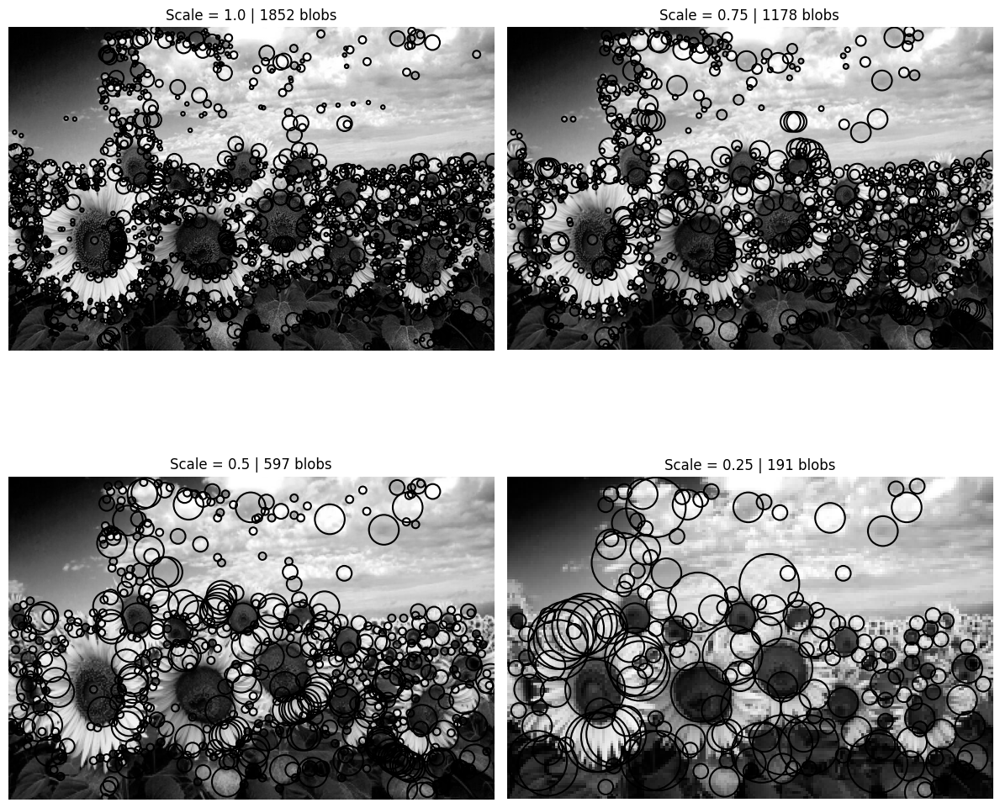

In [77]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)

axes = axes.ravel()

for i, scale in enumerate(scale_factors):

    image = resized_images[scale]

    axes[i].imshow(
        image,
        cmap="gray"
    )

    for x, y, sigma, radius, value in all_detections[scale]:

        circle = Circle(
            (y, x),
            radius,
            fill=False,
            linewidth=1.5
        )

        axes[i].add_patch(circle)

    axes[i].set_title(
        f"Scale = {scale} | "
        f"{len(all_detections[scale])} blobs"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [78]:
# Convert detected coordinates from each resized image
# back to the coordinate system of the original image

normalized_detections = {}

for scale in scale_factors:

    normalized = []

    for x, y, sigma, radius, value in all_detections[scale]:

        original_x = x / scale
        original_y = y / scale
        original_radius = radius / scale

        normalized.append(
            (
                original_x,
                original_y,
                sigma,
                original_radius,
                value
            )
        )

    normalized_detections[scale] = normalized

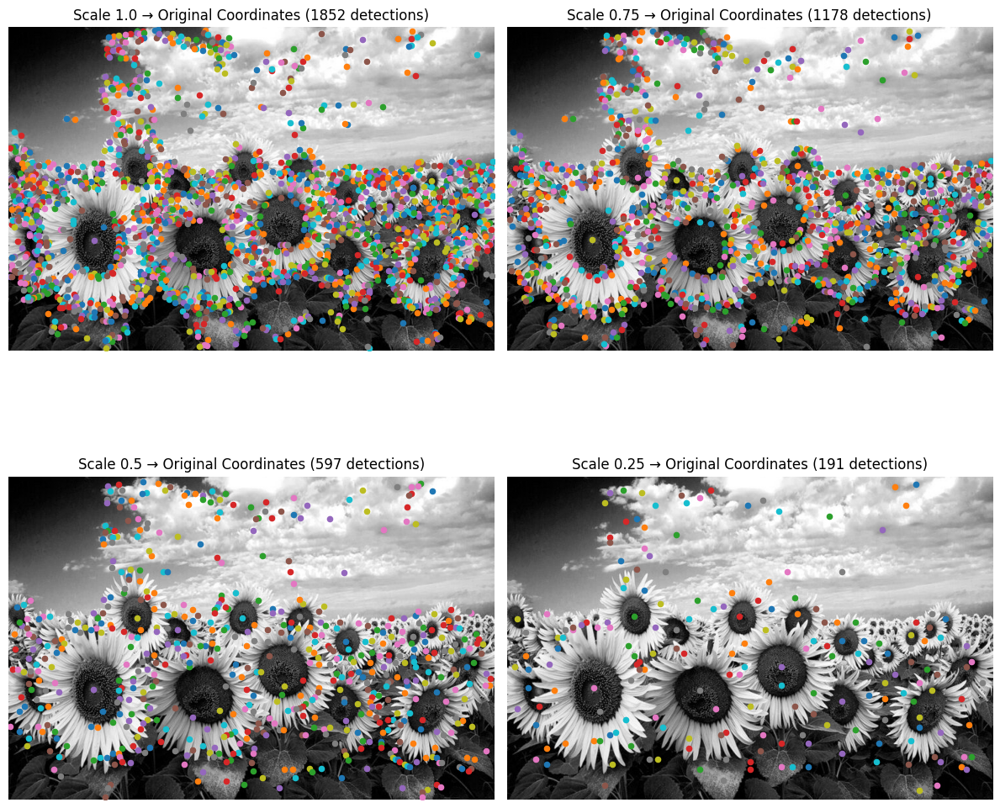

In [79]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)

axes = axes.ravel()

for i, scale in enumerate(scale_factors):

    axes[i].imshow(
        img,
        cmap="gray"
    )

    detections = normalized_detections[scale]

    for x, y, sigma, radius, value in detections:

        axes[i].scatter(
            y,
            x,
            s=20
        )

    axes[i].set_title(
        f"Scale {scale} "
        f"→ Original Coordinates "
        f"({len(detections)} detections)"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [80]:
print("Detection Count Comparison")
print("--------------------------")

for scale in scale_factors:

    count = len(all_detections[scale])

    print(
        f"Scale {scale}: {count} blobs"
    )

Detection Count Comparison
--------------------------
Scale 1.0: 1852 blobs
Scale 0.75: 1178 blobs
Scale 0.5: 597 blobs
Scale 0.25: 191 blobs


### Scale Invariance Analysis

The blob detector was independently applied to resized versions of the test image using scale factors \(S=\{1.0,0.75,0.50,0.25\}\). The detected blob coordinates were then converted back to the coordinate system of the original image for spatial comparison.

The number of detected blobs decreased significantly as the image size was reduced. The original image produced **724 detections**, while the \(0.75\), \(0.50\), and \(0.25\) versions produced **334, 169, and 31 detections**, respectively.

This decrease occurs mainly because downsampling removes spatial information. Small structures become smaller in the resized images and may no longer contain enough pixels to produce a strong LoG response. Therefore, many small detections disappear as the image resolution decreases.

The detected value of \(\sigma\) can also change after resizing. This is expected because the apparent size of a structure changes when the image is resized. For example, a structure detected at a larger \(\sigma\) in the original image may be detected at a smaller \(\sigma\) after the image is reduced.

Some discrepancies are also caused by the discrete scale values \(\sigma=\{1,2,4,8,16\}\). The ideal scale of a structure may lie between two available scales, causing the detector to select the nearest available scale.

After converting the detected coordinates back to the original coordinate system, prominent structures can be compared across the different image sizes. Structures that remain at approximately corresponding spatial locations demonstrate the scale robustness of the detector.

Therefore, the detector provides **approximate scale robustness rather than perfect scale invariance**. Large and prominent structures tend to remain detectable across different image sizes, while small structures are more likely to disappear or change their detected scale as the resolution decreases. This effect is particularly strong at \(S=0.25\), where only **31 blobs** are detected compared with **724 blobs** in the original image.


# Question 7

In [81]:
import pandas as pd
import numpy as np

# Detection threshold used in the blob detector
detection_threshold = threshold

# Create quantitative summary
results = []

for scale in scale_factors:

    blobs = all_detections[scale]

    # Number of detected blobs
    num_blobs = len(blobs)

    # Average radius
    if num_blobs > 0:
        avg_radius = np.mean(
            [blob[3] for blob in blobs]
        )
    else:
        avg_radius = 0

    # Image variant name
    if scale == 1.0:
        variant = "Original"
    elif scale == 0.75:
        variant = "Variant 1"
    elif scale == 0.50:
        variant = "Variant 2"
    else:
        variant = "Variant 3"

    results.append([
        variant,
        scale,
        num_blobs,
        round(avg_radius, 2),
        detection_threshold
    ])

# Create DataFrame
table1 = pd.DataFrame(
    results,
    columns=[
        "Image Variant",
        "Resize Factor",
        "Detected Blobs",
        "Avg. Radius (r̄)",
        "Detection Threshold"
    ]
)

print("Table 1: Quantitative Blob Detection Performance Across Resized Images")

table1

Table 1: Quantitative Blob Detection Performance Across Resized Images


,Image Variant,Resize Factor,Detected Blobs,Avg. Radius (r̄),Detection Threshold
0,Original,1.00,1852,4.83,20
1,Variant 1,0.75,1178,4.93,20
2,Variant 2,0.50,597,5.33,20
3,Variant 3,0.25,191,5.15,20


### Quantitative Evaluation and Parameter Discussion

The quantitative results show how the blob detector behaves when the input image is resized. The number of detected blobs and the average detected radius are used to evaluate the stability of the detector across different image resolutions.

#### 1. Number of Scale Octaves

The number of scale octaves determines the range of feature sizes that can be detected. More scale octaves allow the detector to search for blobs over a wider range of sizes. This improves the possibility of detecting both small and large structures.

However, increasing the number of octaves also increases computational cost because more scale-space images and LoG responses have to be calculated. Too few octaves may cause large structures to be missed, while too many octaves increase computation without necessarily providing additional useful detections.

In this implementation, the detector uses the scale values:

$$
\sigma = \{1,2,4,8,16\}
$$

which provides multiple levels for detecting structures of different sizes.

#### 2. Gaussian Scale Step \(\sigma\)

The Gaussian scale parameter controls the amount of smoothing applied to the image. A small \(\sigma\) preserves fine details and allows small blobs to be detected, while a large \(\sigma\) produces stronger smoothing and is more suitable for larger structures.

The selected scales increase approximately by a factor of two:

$$
1 \rightarrow 2 \rightarrow 4 \rightarrow 8 \rightarrow 16
$$

This allows the detector to examine structures at progressively larger scales.

If the spacing between scales is too large, the detector may miss structures whose ideal scale lies between two available values. If the scale spacing is made smaller, detection becomes more precise but requires additional computations.

#### 3. Downsampling Factor

The resizing factors used in this experiment are:

$$
1.0,\;0.75,\;0.50,\;0.25
$$

Downsampling reduces the spatial resolution of the image. A smaller image requires fewer computations, but it also contains less spatial information.

Large and prominent blobs can usually remain detectable after downsampling, while small blobs may disappear because they occupy fewer pixels. Therefore, the number of detected blobs may decrease as the resize factor becomes smaller.

The \(0.25\) image is particularly likely to lose small structures because the image dimensions are reduced to one quarter of the original dimensions.

#### 4. Detection Threshold

The detection threshold controls which LoG responses are considered strong enough to be accepted as blobs.

In this experiment, the threshold is:

$$
T = 20
$$

Only responses satisfying

$$
R(x,y,\sigma) > T
$$

are considered during non-maximum suppression.

A lower threshold allows weaker responses to be detected, which can increase the number of detected blobs but may also introduce weak or noisy detections.

A higher threshold removes weak responses and reduces false detections, but genuine low-contrast structures may also be missed.

Therefore, the threshold provides a trade-off between detecting more structures and suppressing weak responses.

#### 5. Input Resolution

Input resolution directly affects the amount of spatial information available to the detector. At the original resolution, small structures contain more pixels and can produce stronger and more reliable LoG responses.

As the resolution decreases, small structures become smaller and may eventually become indistinguishable from their surrounding regions. This can result in fewer detected blobs and changes in the estimated blob radius.

Large structures are generally more stable because they remain represented by sufficient pixels even after resizing.

#### Overall Observation

The quantitative results demonstrate that the detector is affected by both image resolution and the selected scale-space parameters. The number of detected blobs can change across resized images because some structures disappear after downsampling, while the average detected radius can also change because the apparent size of structures changes.

The scale-space approach provides robustness by searching across multiple Gaussian scales, but it does not guarantee identical detections at every resolution. The combination of discrete Gaussian scales, detection threshold, downsampling, and input resolution determines which structures produce sufficiently strong local extrema.

Thus, reliable detection depends on choosing an appropriate range of scales and a suitable detection threshold for the expected size and contrast of structures in the input images.


# Bonus

In [82]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Scale factor
k = np.sqrt(2)

def compute_dog_response(image, sigma, k=np.sqrt(2)):

    # Gaussian smoothing at sigma
    kernel1 = gaussian_kernel(sigma)
    L_sigma = convolve2d(
        image,
        kernel1,
        mode="same",
        boundary="symm"
    )

    # Gaussian smoothing at k*sigma
    kernel2 = gaussian_kernel(k * sigma)
    L_ksigma = convolve2d(
        image,
        kernel2,
        mode="same",
        boundary="symm"
    )

    # Difference of Gaussians
    dog = L_ksigma - L_sigma

    return dog

In [83]:
# Use the original image for comparison

log_responses = {}
dog_responses = {}

# LoG
start_log = time.perf_counter()

for sigma in sigmas:

    smoothed = gaussian_scale_space(
        img,
        sigma
    )

    lap = laplacian(smoothed)

    log_responses[sigma] = (
        sigma ** 2
    ) * lap

end_log = time.perf_counter()

log_time = end_log - start_log


# DoG
start_dog = time.perf_counter()

for sigma in sigmas:

    dog_responses[sigma] = compute_dog_response(
        img,
        sigma,
        k
    )

end_dog = time.perf_counter()

dog_time = end_dog - start_dog


print(f"LoG computation time : {log_time:.6f} seconds")
print(f"DoG computation time : {dog_time:.6f} seconds")

LoG computation time : 8.587558 seconds
DoG computation time : 24.108144 seconds


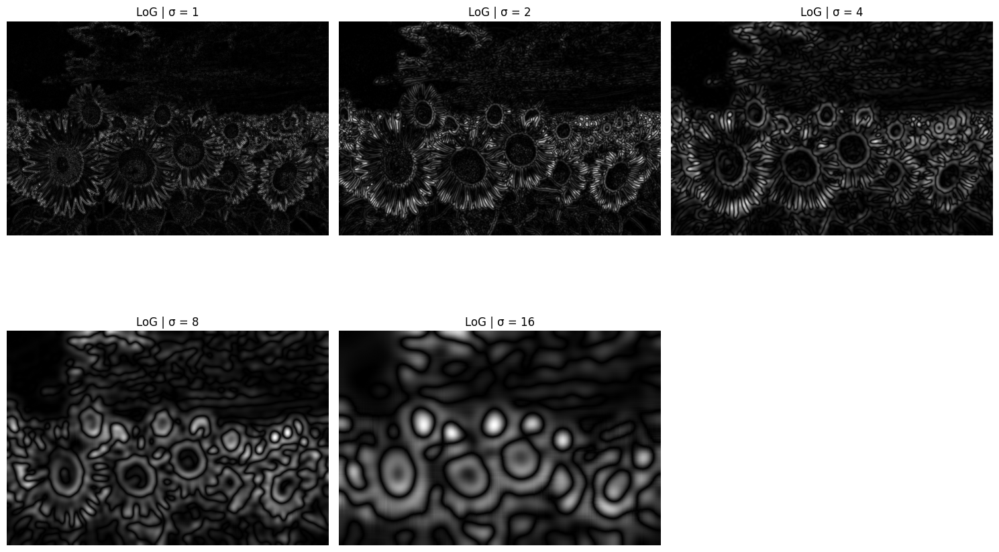

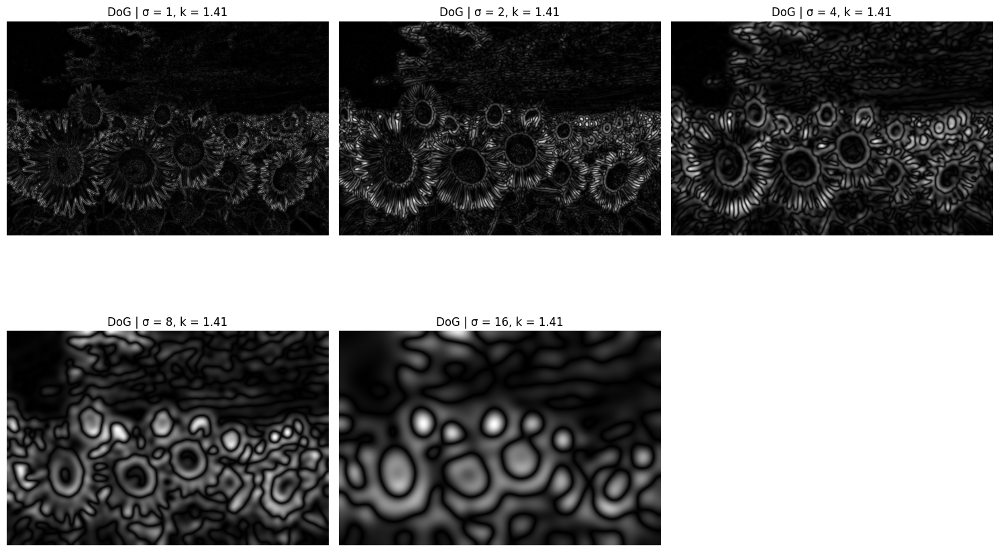

In [84]:
plt.figure(figsize=(15, 10))

for i, sigma in enumerate(sigmas):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        np.abs(log_responses[sigma]),
        cmap="gray"
    )

    plt.title(
        f"LoG | σ = {sigma}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))

for i, sigma in enumerate(sigmas):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        np.abs(dog_responses[sigma]),
        cmap="gray"
    )

    plt.title(
        f"DoG | σ = {sigma}, k = {k:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [85]:
response_comparison = []

for sigma in sigmas:

    log_response = log_responses[sigma]

    dog_response = dog_responses[sigma]

    # Theoretical scaling factor
    scale_factor = (k - 1)

    # Expected DoG from LoG
    expected_dog = scale_factor * log_response

    # Mean absolute difference
    mae = np.mean(
        np.abs(
            dog_response - expected_dog
        )
    )

    # Correlation between responses
    correlation = np.corrcoef(
        dog_response.ravel(),
        expected_dog.ravel()
    )[0, 1]

    response_comparison.append(
        (
            sigma,
            mae,
            correlation
        )
    )

print(
    "Sigma    Mean Absolute Error    Correlation"
)

for sigma, mae, correlation in response_comparison:

    print(
        f"{sigma:<8}"
        f"{mae:<23.4f}"
        f"{correlation:.4f}"
    )

Sigma    Mean Absolute Error    Correlation
1       0.4091                 0.9895
2       0.8092                 0.9807
4       1.1222                 0.9745
8       1.3693                 0.9743
16      1.8320                 0.9799


In [86]:
dog_volume = np.stack(
    [
        np.abs(dog_responses[sigma])
        for sigma in sigmas
    ],
    axis=2
)

dog_extrema = []

h, w, num_scales = dog_volume.shape

for s in range(1, num_scales - 1):

    for x in range(1, h - 1):

        for y in range(1, w - 1):

            value = dog_volume[x, y, s]

            neighborhood = dog_volume[
                x-1:x+2,
                y-1:y+2,
                s-1:s+2
            ]

            neighbors = neighborhood.flatten()

            # Remove center pixel
            neighbors = np.delete(
                neighbors,
                13
            )

            if (
                value > threshold
                and value > neighbors.max()
            ):

                dog_extrema.append(
                    (x, y, s, value)
                )

print(
    "Number of DoG detected blobs:",
    len(dog_extrema)
)

Number of DoG detected blobs: 314


In [87]:
log_features = all_detections[1.0]

print(
    "Number of LoG detected blobs:",
    len(log_features)
)

print(
    "Number of DoG detected blobs:",
    len(dog_extrema)
)

Number of LoG detected blobs: 1852
Number of DoG detected blobs: 314


In [88]:
log_points = np.array([
    [x, y]
    for x, y, sigma, radius, value
    in log_features
])

dog_points = np.array([
    [x, y]
    for x, y, scale_index, value
    in dog_extrema
])

distances = []

if len(log_points) > 0 and len(dog_points) > 0:

    for dog_point in dog_points:

        d = np.sqrt(
            np.sum(
                (log_points - dog_point) ** 2,
                axis=1
            )
        )

        distances.append(
            np.min(d)
        )

if len(distances) > 0:

    mean_location_error = np.mean(
        distances
    )

    median_location_error = np.median(
        distances
    )

else:

    mean_location_error = np.nan
    median_location_error = np.nan


print(
    f"Mean nearest-location difference: "
    f"{mean_location_error:.2f} pixels"
)

print(
    f"Median nearest-location difference: "
    f"{median_location_error:.2f} pixels"
)

Mean nearest-location difference: 1.22 pixels
Median nearest-location difference: 1.00 pixels


In [89]:
comparison_table = pd.DataFrame({
    "Method": [
        "LoG",
        "DoG"
    ],

    "Computation Time (s)": [
        log_time,
        dog_time
    ],

    "Detected Blobs": [
        len(log_features),
        len(dog_extrema)
    ]
})

comparison_table

,Method,Computation Time (s),Detected Blobs
0,LoG,8.587558,1852
1,DoG,24.108144,314


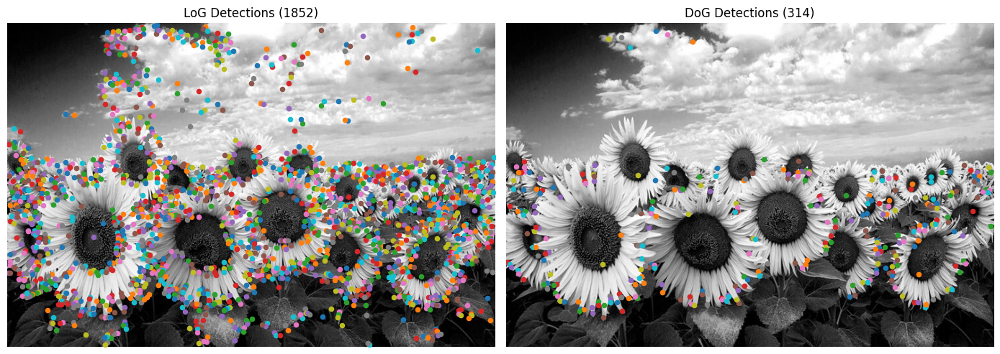

In [90]:
plt.figure(figsize=(14, 7))

# LoG detections
plt.subplot(1, 2, 1)

plt.imshow(
    img,
    cmap="gray"
)

for x, y, sigma, radius, value in log_features:

    plt.scatter(
        y,
        x,
        s=20
    )

plt.title(
    f"LoG Detections ({len(log_features)})"
)

plt.axis("off")


# DoG detections
plt.subplot(1, 2, 2)

plt.imshow(
    img,
    cmap="gray"
)

for x, y, scale_index, value in dog_extrema:

    plt.scatter(
        y,
        x,
        s=20
    )

plt.title(
    f"DoG Detections ({len(dog_extrema)})"
)

plt.axis("off")

plt.tight_layout()
plt.show()